<a href="https://colab.research.google.com/github/Asmitpremkumar16/Customer_Churn/blob/main/Churn_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Asmitpremkumar16/Customer_Churn.git

Cloning into 'Customer_Churn'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 32 (delta 10), reused 13 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 554.12 KiB | 2.76 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [2]:
%cd Customer_Churn/

/content/Customer_Churn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [128]:
data= pd.read_csv(r"/content/Customer_Churn/churn modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [129]:
data.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [130]:
data.duplicated().sum()

np.int64(0)

In [131]:
data["Exited"].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


In [132]:
data.groupby('Geography')['Exited'].mean() * 100

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


In [133]:
data.groupby('Gender')['Exited'].mean() * 100

,Exited
Gender,
Female,25.071539
Male,16.455928


In [134]:
data.groupby(['Geography','Gender'])['Exited'].mean() * 100

Geography  Gender
France     Female    20.344980
           Male      12.713404
Germany    Female    37.552389
           Male      27.811550
Spain      Female    21.212121
           Male      13.112392
Name: Exited, dtype: float64

In [135]:
data.groupby(['Gender','IsActiveMember'])['Exited'].mean() * 100

Gender  IsActiveMember
Female  0                 32.093847
        1                 18.126095
Male    0                 22.277992
        1                 11.196373
Name: Exited, dtype: float64

In [136]:
data.groupby(['NumOfProducts','IsActiveMember'])['Exited'].mean() * 100

NumOfProducts  IsActiveMember
1              0                  36.652122
               1                  18.923137
2              0                   9.888060
               1                   5.560098
3              0                  88.235294
               1                  75.221239
4              0                 100.000000
               1                 100.000000
Name: Exited, dtype: float64

In [137]:
data.groupby(['HasCrCard'])['Exited'].mean() * 100

,Exited
HasCrCard,
0,20.814941
1,20.184266


In [138]:
fig1= px.histogram(data, x= "Geography", color= "IsActiveMember",facet_col= "Exited", barmode= "group", title= "Geography by Exited", text_auto= True)
fig1.update_traces(textposition= 'outside')
fig1.show(renderers= "notebook_connected")

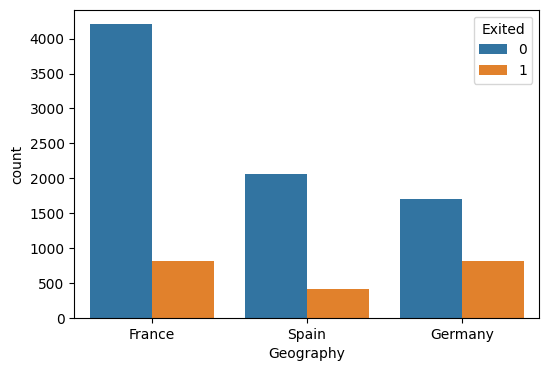

In [139]:
plt.figure(figsize=(6,4))
sns.countplot(data= data, x= "Geography", hue= "Exited")
plt.show()

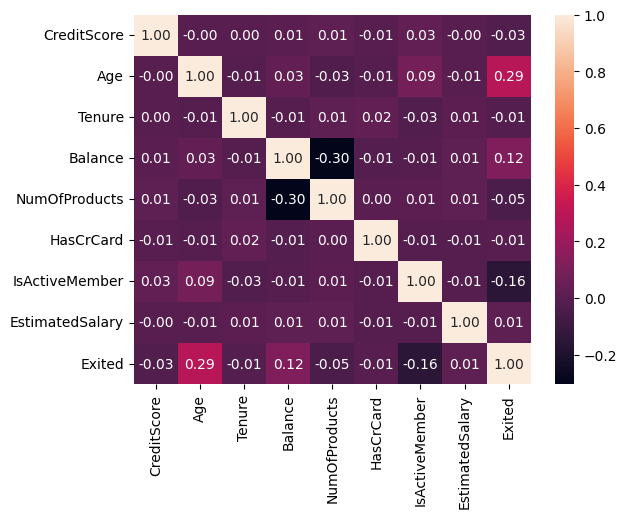

In [140]:
df= data[["CreditScore","Age","Tenure","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary","Exited"]].corr()
sns.heatmap(df, annot= True, fmt= ".2f")
plt.show()

In [141]:
fig2= px.imshow(df, text_auto= ".2f",title= "Correlation Heatmap")
fig2.update_layout(width= 700, height= 600)
fig2.show(renderers= "notebook_connected")

In [142]:
data['Age'].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


In [143]:
fig5= px.histogram(data, x= "Age", color= "Exited", barmode= 'overlay', title= "Age Distribution Churned vs Retained", opacity= 0.6)
fig5.show(renderers= "notebook_connected")

In [144]:
fig6= px.histogram(data, x= "EstimatedSalary", color= "Exited", opacity= 0.6, title= "Churn across different Balance")
fig6.show(renderers= "notebook_connected")

In [145]:
data =data.drop(columns=['RowNumber','CustomerId','Surname'], axis=1)
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [146]:
data= pd.get_dummies(data, columns=['Geography','Gender'], drop_first= True).astype(int)
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0


In [147]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X= data.drop(columns= ['Exited'])
y= data['Exited']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

sm= SMOTE(random_state= 42)
X_train_res, y_train_res= sm.fit_resample(X_train, y_train)

In [148]:
y_train_res.value_counts(normalize=True) * 100

,proportion
Exited,
1,50.0
0,50.0


In [151]:
len(X_train_res['CreditScore'])

12740

In [152]:
from sklearn.preprocessing import StandardScaler

cols_to_scale= ['CreditScore','Age','Tenure','Balance','EstimatedSalary']

scaler= StandardScaler()
X_train_res[cols_to_scale]= scaler.fit_transform(X_train_res[cols_to_scale])
X_test[cols_to_scale]= scaler.transform(X_test[cols_to_scale])

In [155]:
X_train_res.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,1.135426,1.600708,0.787418,-1.348934,1,1,0,1.017880,0,0,1
1,0.982550,-0.893204,-0.681030,0.327482,1,1,0,-0.641254,1,0,1
2,1.157265,-0.394422,-1.782367,0.520144,2,1,1,0.286790,1,0,0
3,-0.961159,-0.394422,0.053194,-1.348934,2,1,0,-0.309198,0,0,1
4,0.469323,0.802656,0.420306,0.465564,2,0,1,0.114368,1,0,1


In [160]:
X_train_res.shape

(12740, 11)

In [161]:
y_train_res.value_counts()

,count
Exited,
1,6370
0,6370


In [165]:
(X_train_res[cols_to_scale].describe())

,CreditScore,Age,Tenure,Balance,EstimatedSalary
count,1.274000e+04,1.274000e+04,1.274000e+04,1.274000e+04,1.274000e+04
mean,-1.048525e-16,3.569445e-16,-8.477433e-17,9.815975e-17,6.915801e-17
std,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00
min,-3.265219e+00,-2.289796e+00,-1.782367e+00,-1.348934e+00,-1.752683e+00
25%,-6.881664e-01,-6.936914e-01,-6.810304e-01,-1.348934e+00,-8.500094e-01
50%,1.069515e-02,-9.515236e-02,5.319379e-02,3.482882e-01,8.463743e-03
75%,6.877173e-01,6.031432e-01,7.874180e-01,7.676797e-01,8.541234e-01
max,2.194638e+00,5.092186e+00,1.888754e+00,2.564155e+00,1.721831e+00
